# INTRODUCCION

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import sys

#READ DATASET
df= pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
#Dataset information
df.shape
df.head()
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

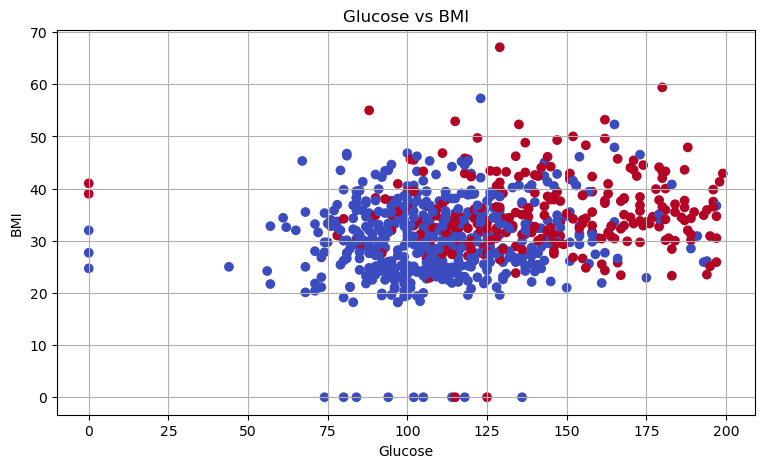

In [3]:
#GRAFICAR
plt.figure(figsize=(9,5))

plt.scatter(df['Glucose'], df['BMI'], c=df['Outcome'], cmap='coolwarm')

plt.title('Glucose vs BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')

plt.grid(True)
plt.show()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
12           140      82             43             325      39.2  0.528                     58   1          1
             121      78             17             0        26.5  0.259                     62   0          1
             106      80             0              0        23.6  0.137                     44   0          1
             100      84             33             105      30.0  0.488                     46   0          1
             92       62             7              258      27.6  0.926                     44   1          1
                                                                                                            ..
0            78       88             29             40       36.9  0.434                     21   0          1
             74       52             10             36       27.8  0.269                     22   0          1
      

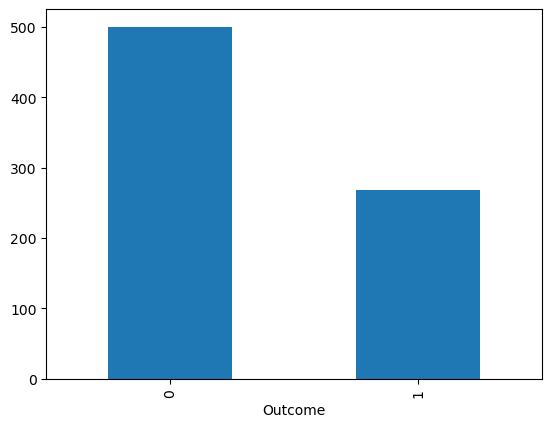

In [4]:
df['Outcome'].value_counts().plot(kind='bar')
df.value_counts()

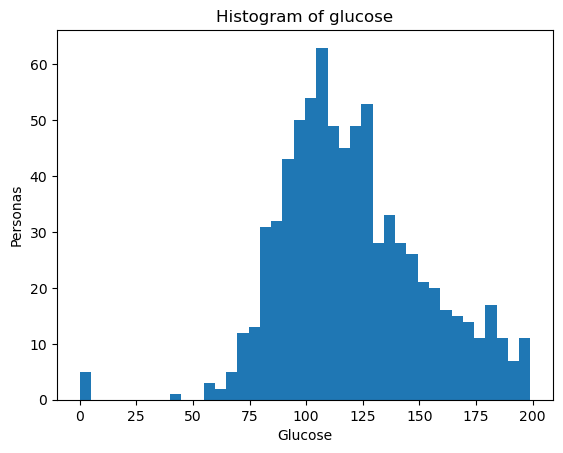

In [5]:
plt.hist(df['Glucose'], bins=40)
plt.xlabel('Glucose')
plt.ylabel('Personas')
plt.title('Histogram of glucose')
plt.show()
#HISTOGRAM BEFORE MEDIAN

<Axes: >

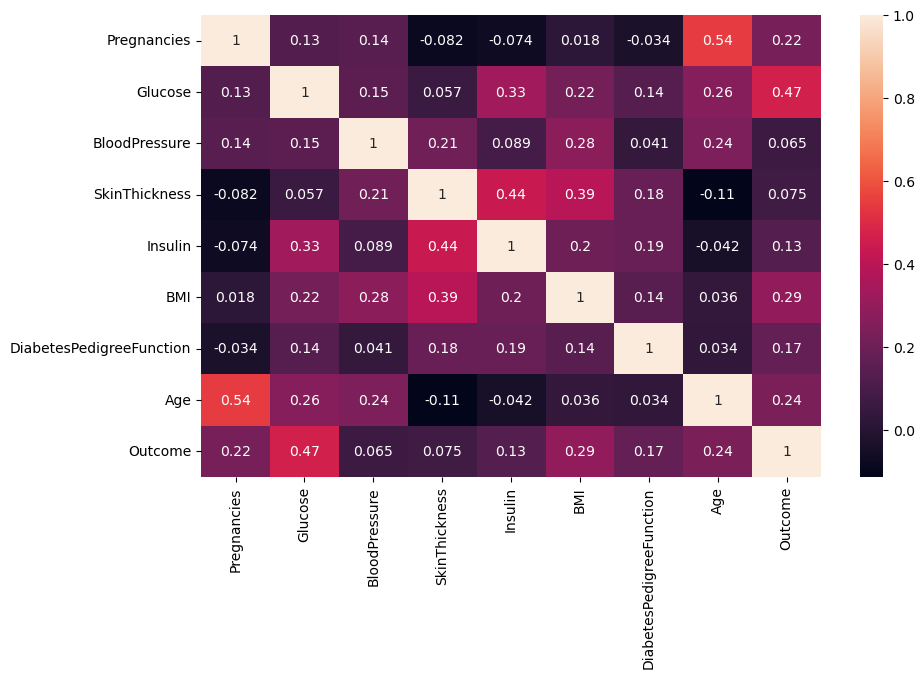

In [6]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='Outcome', ylabel='Age'>

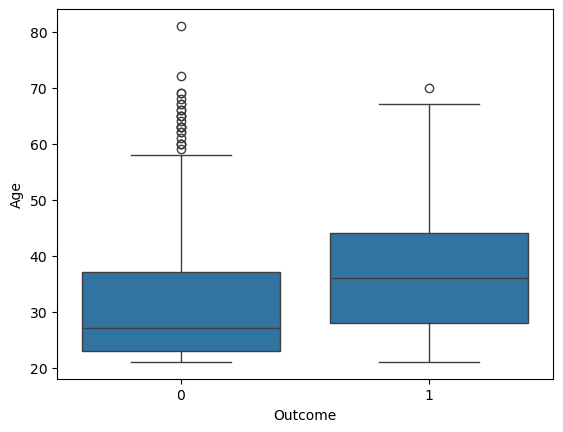

In [7]:
sns.boxplot(x='Outcome', y='Age', data=df)

In [8]:
for col in df.columns:
    print(col, (df[col] == 0).sum())
    
df[df['Glucose'] == 0]

Pregnancies 111
Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11
DiabetesPedigreeFunction 0
Age 0
Outcome 500


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [9]:
#LIMPIEZA DE DATOS
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

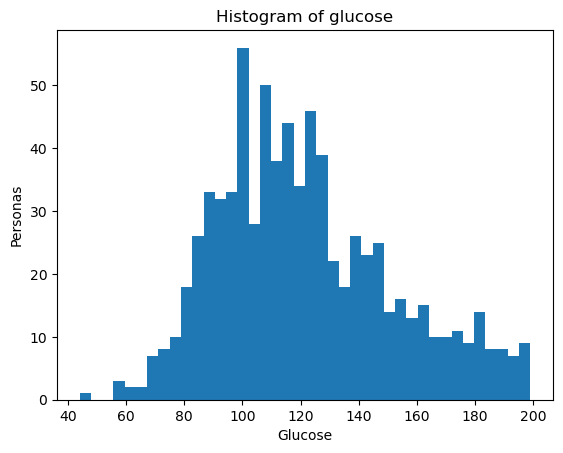

In [10]:
plt.hist(df['Glucose'], bins=40)
plt.xlabel('Glucose')
plt.ylabel('Personas')
plt.title('Histogram of glucose')
plt.show()

In [11]:
print(df)
X = df.drop('Outcome', axis=1)
y = df['Outcome']
#print(X)
#print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35     30.5  33.6   
1              1       85             66             29     30.5  26.6   
2              8      183             64             23     30.5  23.3   
3              1       89             66             23     94.0  28.1   
4              0      137             40             35    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48    180.0  32.9   
764            2      122             70             27     30.5  36.8   
765            5      121             72             23    112.0  26.2   
766            1      126             60             23     30.5  30.1   
767            1       93             70             31     30.5  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Escalar datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
#MODELOS
#Regresion lineal
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

In [15]:
#Arboles de decision
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

In [16]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier()
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)

In [17]:
#Evaluation de modelos
from sklearn.metrics import accuracy_score

print("Logistic:", accuracy_score(y_test, pred1))
print("Decision Tree:", accuracy_score(y_test, pred2))
print("Random Forest:", accuracy_score(y_test, pred3))

Logistic: 0.7662337662337663
Decision Tree: 0.6883116883116883
Random Forest: 0.7467532467532467


Text(50.722222222222214, 0.5, 'Actual')

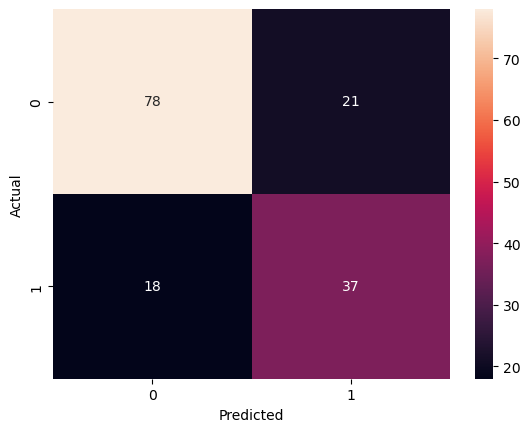

In [18]:
#Matriz de confusion
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred3)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



<Axes: >

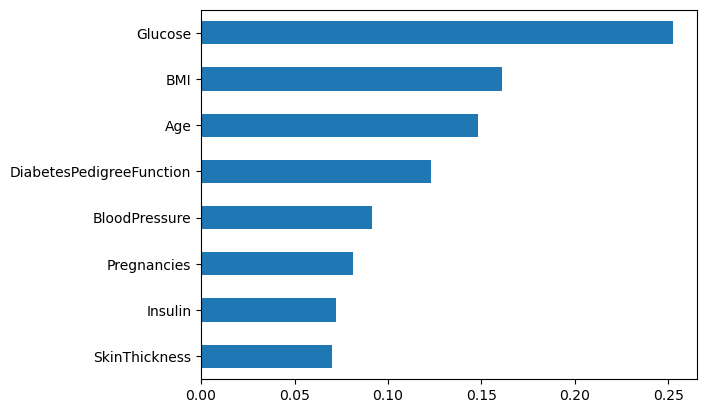

In [20]:
importance = model3.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh')

In [21]:
def predecir_diabetes(datos_paciente):
    
    datos_paciente = scaler.transform([datos_paciente])
    pred = model2.predict(datos_paciente)
    print(pred)
    if pred[0] == 1:
        return "Paciente con riesgo de diabetes"
    else:
        return "Paciente sin diabetes"

#Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome    
predecir_diabetes([0,20,80,25,100,20,0.2,20])



[0]


c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Paciente sin diabetes'

In [22]:
import joblib

joblib.dump(model3, "../models/diabetes_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [23]:
import sklearn
print(sklearn.__version__)

1.6.1
